# 06 - Potpuno povezana neuronska mreža

U ovoj svesci učimo poslednji model iz plana projekta, potpuno povezanu neuronsku mrežu za regresiju. Mreža, kao i slučajna šuma, može da nauči nelinearnu vezu između atributa i interakcije među njima, ali to radi na drugačiji način: kompozicijom linearnih transformacija i nelinearnih aktivacionih funkcija.

Koristimo biblioteku Keras iz paketa TensorFlow. Ulaz mreže su isti atributi kao za prethodne modele, standardizovani, a izlaz je jedan broj, predviđeni broj iznajmljivanja.

Sveska čita podatke iz sveske 02 i rezultate iz sveske 04, pa je potrebno prethodno pokrenuti te sveske.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn import preprocessing
from sklearn import metrics

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import callbacks

Obučavanje mreže ima više izvora slučajnosti, početne vrednosti težina i redosled instanci pri obučavanju. Da bi rezultati bili ponovljivi, postavljamo seme.

In [2]:
 np.random.seed(7)
tf.keras.utils.set_random_seed(7)

In [3]:
print('verzija TensorFlow:', tf.__version__)
print('verzija Keras:     ', tf.keras.__version__)

verzija TensorFlow: 2.21.0
verzija Keras:      3.15.1


# Učitavanje pripremljenih podataka

In [4]:
paket = joblib.load('../data/pripremljeno.joblib')

X = paket['X']
y = paket['y']
kolone = paket['kolone']

h_trening = paket['h_trening']
h_validacija = paket['h_validacija']
h_test = paket['h_test']

n_trening = paket['n_trening']
n_validacija = paket['n_validacija']
n_test = paket['n_test']

In [5]:
x_train = X[h_trening]
y_train = y[h_trening]

x_validation = X[h_validacija]
y_validation = y[h_validacija]

x_test = X[h_test]
y_test = y[h_test]

h_trening_validacija = h_trening | h_validacija
x_train_validation = X[h_trening_validacija]
y_train_validation = y[h_trening_validacija]

print('trening:           ', x_train.shape)
print('validacija:        ', x_validation.shape)
print('trening+validacija:', x_train_validation.shape)
print('test:              ', x_test.shape)

trening:            (6916, 52)
validacija:         (1729, 52)
trening+validacija: (8645, 52)
test:               (8734, 52)


In [6]:
number_of_features = x_train.shape[1]
number_of_features

52

# Standardizacija podataka

Neuronske mreže se obučavaju gradijentnim spustom, a on je osetljiv na razmere atributa. Ako su atributi različitih razmera, funkcija greške je izdužena i gradijentni spust sporo napreduje. Zato standardizujemo ulaz, kao i za metod najbližih suseda.

Statistike učimo samo na podacima koji ulaze u obučavanje.

In [7]:
scaler = preprocessing.StandardScaler()
scaler.fit(x_train)

x_train_s = scaler.transform(x_train)
x_validation_s = scaler.transform(x_validation)

In [8]:
scaler_final = preprocessing.StandardScaler()
scaler_final.fit(x_train_validation)

x_train_validation_s = scaler_final.transform(x_train_validation)
x_test_s = scaler_final.transform(x_test)

# Funkcija za evaluaciju

In [9]:
def oceni(y_stvarno, y_predvidjeno, naziv):
    mae = metrics.mean_absolute_error(y_stvarno, y_predvidjeno)
    rmse = np.sqrt(metrics.mean_squared_error(y_stvarno, y_predvidjeno))
    r2 = metrics.r2_score(y_stvarno, y_predvidjeno)
    odstupanje = np.mean(y_predvidjeno - y_stvarno)
    print('%-38s MAE %6.1f  RMSE %6.1f  R2 %6.3f  odstupanje %+7.1f'
          % (naziv, mae, rmse, r2, odstupanje))
    return {'model': naziv, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'odstupanje': odstupanje}

Učitavamo rezultate prethodnih modela iz sveske 04.

In [10]:
prethodni = pd.read_csv('../models/04_rezultati.csv')
prethodni

,model,MAE,RMSE,R2,odstupanje
0,trivijalna osnova,108.516420,157.050770,0.434793,-91.874310
1,linearna regresija,110.178359,158.026226,0.427750,-86.714670
2,linearna regresija sa težinama,110.296560,161.012460,0.405918,-88.131800
3,k najbližih suseda,116.345356,168.543531,0.349044,-102.667412
4,slučajna šuma,92.985588,129.737505,0.614292,-81.235518


In [11]:
rezultati = prethodni.to_dict('records')

# Prva mreža

Počinjemo od jednostavne mreže sa jednim skrivenim slojem od 64 neurona i ReLU aktivacijom. Izlazni sloj ima jedan neuron bez aktivacione funkcije, jer je zadatak regresioni i izlaz može biti bilo koji realan broj.

Mrežu pravimo kao sekvencijalni model, sloj po sloj. Prvi element je ulazni sloj kome zadajemo broj atributa.

In [12]:
model = Sequential([
    Input(shape=(number_of_features, )),
    Dense(units=64, activation='relu'),
    Dense(units=1)
])

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

Mreža ima 52 ulaza, 64 neurona u skrivenom sloju i jedan izlaz. Broj parametara je 52 * 64 + 64 = 3392 za skriveni sloj i 64 + 1 = 65 za izlazni sloj, ukupno 3457.

Pre obučavanja model se kompajlira. Funkcija greške je srednja kvadratna greška, kao i kod linearne regresije. Optimizator je Adam, varijanta gradijentnog spusta koja sama prilagođava korak učenja. Pored greške pratimo i srednju apsolutnu grešku, jer je nju lakše tumačiti, u broju bicikala.

In [14]:
model.compile(loss='mse', optimizer='adam', metrics=['mae'])

Obučavamo mrežu 100 epoha, u paketićima (eng. batch) od 32 instance. Prosleđujemo i skup za validaciju, da bismo videli kako se greška na njemu menja tokom obučavanja.

In [15]:
history = model.fit(x_train_s, y_train,
                    epochs=100, batch_size=32, verbose=0,
                    validation_data=(x_validation_s, y_validation))

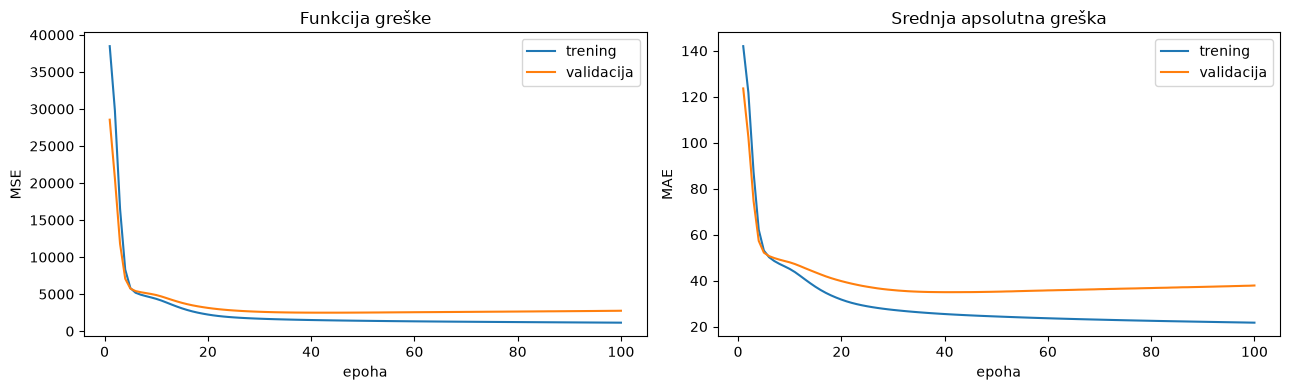

In [16]:
epochs = range(1, len(history.history['loss']) + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(epochs, history.history['loss'], label='trening')
ax[0].plot(epochs, history.history['val_loss'], label='validacija')
ax[0].set_xlabel('epoha')
ax[0].set_ylabel('MSE')
ax[0].set_title('Funkcija greške')
ax[0].legend()

ax[1].plot(epochs, history.history['mae'], label='trening')
ax[1].plot(epochs, history.history['val_mae'], label='validacija')
ax[1].set_xlabel('epoha')
ax[1].set_ylabel('MAE')
ax[1].set_title('Srednja apsolutna greška')
ax[1].legend()

plt.tight_layout()
plt.show()

In [17]:
najbolja_epoha = np.argmin(history.history['val_loss']) + 1

print('MAE na treningu posle 100 epoha:  ', round(history.history['mae'][-1], 1))
print('MAE na validaciji posle 100 epoha:', round(history.history['val_mae'][-1], 1))
print('najmanja MAE na validaciji:       ', round(min(history.history['val_mae']), 1))
print('epoha sa najmanjom greškom:       ', najbolja_epoha)

MAE na treningu posle 100 epoha:   21.7
MAE na validaciji posle 100 epoha: 37.9
najmanja MAE na validaciji:        35.0
epoha sa najmanjom greškom:        43


Greška na treningu opada tokom svih sto epoha, a greška na validaciji opada samo do četrdesetak epoha i posle toga blago raste. Mreža posle toga uči osobine skupa za treniranje koje se ne prenose na nove podatke, dakle preprilagođava se.

Posle sto epoha greška na treningu je oko 22 bicikla, a na validaciji oko 38. Razlika između ta dva broja je mera preprilagođavanja.

# Rano zaustavljanje

Umesto da unapred biramo broj epoha, koristimo rano zaustavljanje. Posle svake epohe proverava se greška na skupu za validaciju i obučavanje se prekida kada ona prestane da opada. Parametar patience je broj epoha koje se čeka pre prekida, a restore_best_weights vraća težine iz epohe sa najmanjom greškom.

Ovo je ujedno i oblik regularizacije, jer sprečava mrežu da nastavi da se preprilagođava.

In [18]:
rano_zaustavljanje = callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                             restore_best_weights=True)

# Izbor arhitekture

Metaparametri mreže su broj skrivenih slojeva i broj neurona u njima. Ispitujemo pet arhitektura, od jednog uskog sloja do tri široka. Svaku obučavamo sa ranim zaustavljanjem i poredimo po grešci na skupu za validaciju.

Pre svakog obučavanja ponovo postavljamo seme, da bi sve mreže krenule od uporedivih početnih uslova.

In [19]:
arhitekture = [[32], [128], [32, 32], [128, 128], [128, 128, 128]]

In [20]:
def napravi_mrezu(skriveni_slojevi):
    slojevi = [Input(shape=(number_of_features, ))]
    for broj_neurona in skriveni_slojevi:
        slojevi.append(Dense(units=broj_neurona, activation='relu'))
    slojevi.append(Dense(units=1))

    model = Sequential(slojevi)
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model

In [21]:
best_score = np.inf
best_arhitektura = None
best_epoha = None
mae_po_arhitekturi = []

for arhitektura in arhitekture:
    tf.keras.utils.set_random_seed(7)

    model = napravi_mrezu(arhitektura)
    history = model.fit(x_train_s, y_train,
                        epochs=200, batch_size=32, verbose=0,
                        validation_data=(x_validation_s, y_validation),
                        callbacks=[rano_zaustavljanje])

    y_validation_predicted = model.predict(x_validation_s, verbose=0).ravel()
    score = metrics.mean_absolute_error(y_validation, y_validation_predicted)
    mae_po_arhitekturi.append(score)

    broj_epoha = np.argmin(history.history['val_loss']) + 1
    print('%-18s parametara %6d  epoha %3d  MAE na validaciji %5.1f'
          % (arhitektura, model.count_params(), broj_epoha, score))

    if score < best_score:
        best_score = score
        best_arhitektura = arhitektura
        best_epoha = broj_epoha

[32]               parametara   1729  epoha  52  MAE na validaciji  37.1
[128]              parametara   6913  epoha  29  MAE na validaciji  36.8
[32, 32]           parametara   2785  epoha  19  MAE na validaciji  36.7
[128, 128]         parametara  23425  epoha  33  MAE na validaciji  31.4
[128, 128, 128]    parametara  39937  epoha  10  MAE na validaciji  31.6


In [22]:
print('najbolja arhitektura:', best_arhitektura)
print('broj epoha:          ', best_epoha)
print('MAE na validaciji:   ', round(best_score, 1))

najbolja arhitektura: [128, 128]
broj epoha:           33
MAE na validaciji:    31.4


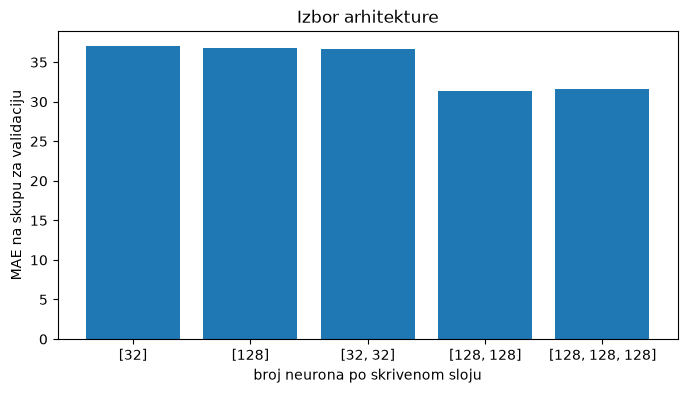

In [23]:
plt.figure(figsize=(8,4))
plt.bar(range(len(arhitekture)), mae_po_arhitekturi)
plt.xticks(range(len(arhitekture)), [str(a) for a in arhitekture])
plt.xlabel('broj neurona po skrivenom sloju')
plt.ylabel('MAE na skupu za validaciju')
plt.title('Izbor arhitekture')
plt.show()

Mreže sa jednim skrivenim slojem i mreža sa dva uska sloja imaju grešku oko 37 bicikala na validaciji. Dva široka sloja spuštaju grešku na oko 31, a treći sloj ne donosi dalje poboljšanje. Biramo mrežu sa dva sloja od po 128 neurona.

Rano zaustavljanje je za sve mreže prekinulo obučavanje mnogo pre dvestote epohe. Najdublja mreža je najranije, već posle deset epoha, počela da se preprilagođava.

# Konačni model

Kao i za prethodne modele, konačnu mrežu obučavamo na uniji skupova za treniranje i validaciju. Pošto tada nemamo skup na kome bi rano zaustavljanje pratilo grešku, obučavamo je fiksan broj epoha, onoliko koliko je najbolja mreža imala u trenutku najmanje greške na validaciji.

In [24]:
tf.keras.utils.set_random_seed(7)

model_mreza = napravi_mrezu(best_arhitektura)
history = model_mreza.fit(x_train_validation_s, y_train_validation,
                          epochs=best_epoha, batch_size=32, verbose=0)

In [25]:
model_mreza.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,277 (274.52 KB)

 Trainable params: 23,425 (91.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 46,852 (183.02 KB)

Kao u vežbama, metodom evaluate dobijamo vrednost funkcije gubitka i srednju
apsolutnu grešku na podacima za obučavanje i na skupu za testiranje.

In [26]:
print('trening+validacija:', model_mreza.evaluate(x_train_validation_s, y_train_validation, verbose=0))
print('test:              ', model_mreza.evaluate(x_test_s, y_test, verbose=0))

trening+validacija: [765.4445190429688, 18.034067153930664]
test:               [15007.5107421875, 88.39437103271484]


Prvi broj je funkcija gubitka, drugi srednja apsolutna greška. Na podacima za obučavanje greška je oko 18 bicikala, a na testu oko 88. Deo razlike je preprilagođavanje, ali najveći deo je nivo potražnje iz 2012. koji mreža nije videla, što se vidi u koloni odstupanja u nastavku.

In [27]:
y_test_predicted_mreza = model_mreza.predict(x_test_s, verbose=0).ravel()

rezultati.append(oceni(y_test, y_test_predicted_mreza, 'neuronska mreža'))

neuronska mreža                        MAE   88.4  RMSE  122.5  R2  0.656  odstupanje   -82.7


Neuronska mreža je najbolji model do sada. Srednja apsolutna greška je nešto ispod 90 bicikala, a koeficijent determinacije oko 0.65, u poređenju sa 93 i 0.61 kod slučajne šume.

Sistematsko odstupanje je i dalje oko -80 bicikala. Ni mreža ne može da predvidi rast potražnje u 2012, jer je u podacima za obučavanje atribut yr uvek nula.

Izlazni neuron nema aktivacionu funkciju, pa mreža može da predvidi i negativan broj
bicikala. Proveravamo koliko je takvih predviđanja.

In [28]:
negativna = y_test_predicted_mreza < 0

print('negativnih predviđanja:', negativna.sum())
print('najmanje predviđanje:  ', round(y_test_predicted_mreza.min(), 1))
print('stvarne vrednosti tada:', y_test[negativna].mean().round(1))

negativnih predviđanja: 394
najmanje predviđanje:   -30.7
stvarne vrednosti tada: 9.7


Negativna predviđanja se javljaju u noćnim satima, kada je stvarna potražnja blizu nule.
Broj bicikala ne može biti negativan, pa takva predviđanja zamenjujemo nulom.

In [29]:
y_test_predicted_mreza = np.maximum(y_test_predicted_mreza, 0)

rezultati[-1] = oceni(y_test, y_test_predicted_mreza, 'neuronska mreža')

neuronska mreža                        MAE   88.1  RMSE  122.5  R2  0.656  odstupanje   -82.4


Popravka smanjuje srednju apsolutnu grešku za svega tri desetine bicikla, jer su greške
u noćnim satima male u odnosu na greške u satima špica.

## Atribut godine

Atribut yr je na treningu uvek 0, jer je trening cela 2011. godina, a na testu uvek 1. Iz takve kolone se ništa ne može naučiti. Linearni modeli joj daju koeficijent nula, šuma po njoj ne grana, a kod najbližih suseda ona sva rastojanja poveća za isto, pa ne menja ko su najbliži.

Kod mreže je drugačije. Težine koje polaze od tog ulaza ostaju na slučajnim početnim vrednostima, jer je ulaz na treningu nula pa se one ne obučavaju. Na testu ulaz postaje jedinica i te težine odjednom počnu da utiču na predviđanje.

Zato proveravamo koliki je taj efekat: na testu vratimo yr na vrednost sa treninga i vidimo koliko se rezultat promeni.

In [30]:
indeks_yr = kolone.index('yr')

x_test_bez_godine = x_test_s.copy()
x_test_bez_godine[:, indeks_yr] = x_train_validation_s[0, indeks_yr]

y_test_predicted_bez_godine = np.maximum(model_mreza.predict(x_test_bez_godine, verbose=0).ravel(), 0)

oceni(y_test, y_test_predicted_mreza, 'neuronska mreža, yr = 1')
oceni(y_test, y_test_predicted_bez_godine, 'neuronska mreža, yr kao u obučavanju')
print()

neuronska mreža, yr = 1                MAE   88.1  RMSE  122.5  R2  0.656  odstupanje   -82.4
neuronska mreža, yr kao u obučavanju   MAE   87.0  RMSE  121.1  R2  0.664  odstupanje   -81.3



Razlika je oko jednog bicikla po satu, pa neobučene težine unose mali šum, ali ne menjaju zaključke. Model zadržavamo kakav jeste, a atribut ostaje u skupu jer je na nasumičnoj podeli informativan.

## Greška po satu u danu

Poredimo grešku mreže i slučajne šume po satu u danu, da bismo videli gde mreža
dobija prednost.

In [31]:
sat = pd.read_csv('../data/hour.csv')
sat_test = sat[h_test]

model_forest = joblib.load('../models/04_slucajna_suma.joblib')
y_test_predicted_forest = model_forest.predict(x_test)

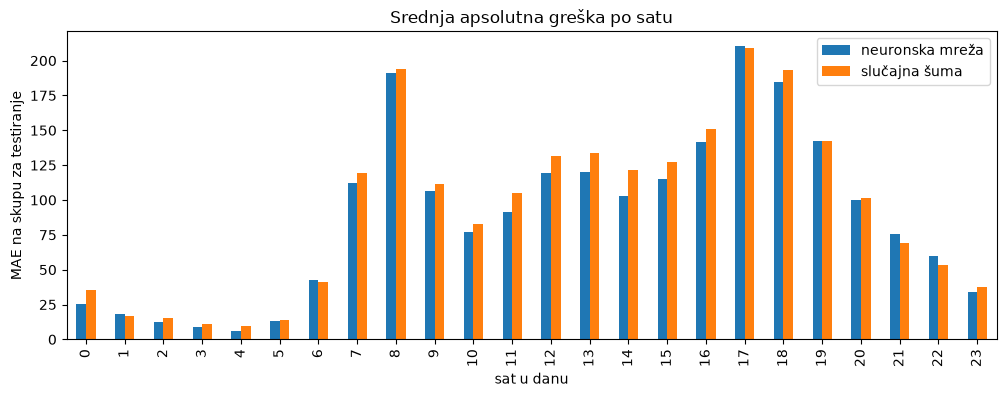

In [32]:
greska_po_satu = pd.DataFrame({
    'neuronska mreža': np.abs(y_test - y_test_predicted_mreza),
    'slučajna šuma': np.abs(y_test - y_test_predicted_forest)
}, index=sat_test['hr'].values).groupby(level=0).mean()

greska_po_satu.plot(kind='bar', figsize=(12, 4))
plt.xlabel('sat u danu')
plt.ylabel('MAE na skupu za testiranje')
plt.title('Srednja apsolutna greška po satu')
plt.show()

Oba modela najviše greše u satima špica, oko 8h i 17h, gde je i potražnja najveća. U tim satima su modeli izjednačeni. Mreža dobija prednost u dnevnim satima između špiceva, najviše između 11h i 16h. U kasnim večernjim satima šuma je nešto bolja, a noću su greške oba modela male.

## Predviđanje za jednu nedelju

Prikazujemo stvarnu i predviđenu potražnju za jednu nedelju iz skupa za testiranje,
od ponedeljka 7. maja 2012.

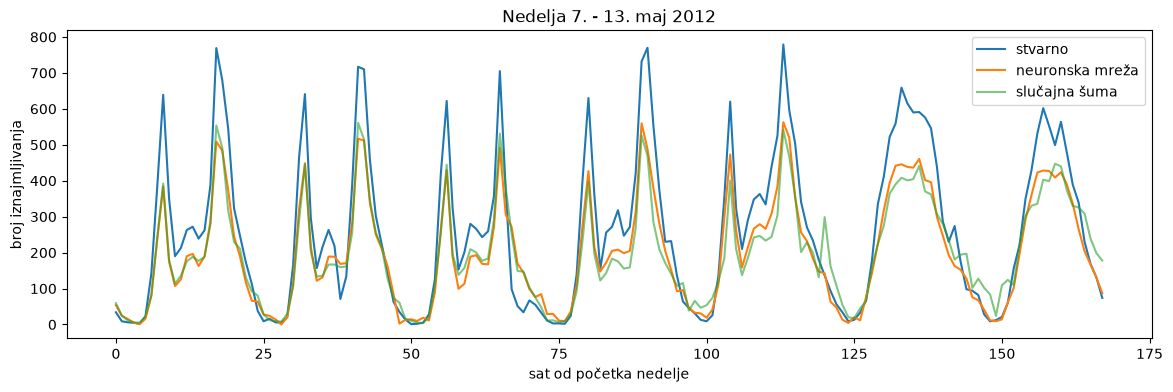

In [33]:
pocetak = sat_test.index[sat_test['dteday'] == '2012-05-07'][0]
kraj = sat_test.index[sat_test['dteday'] == '2012-05-13'][-1]

izbor = (sat_test.index >= pocetak) & (sat_test.index <= kraj)

plt.figure(figsize=(14, 4))
plt.plot(y_test[izbor], label='stvarno')
plt.plot(y_test_predicted_mreza[izbor], label='neuronska mreža')
plt.plot(y_test_predicted_forest[izbor], label='slučajna šuma', alpha=0.6)
plt.xlabel('sat od početka nedelje')
plt.ylabel('broj iznajmljivanja')
plt.title('Nedelja 7. - 13. maj 2012')
plt.legend()
plt.show()

Oba modela tačno pogađaju oblik dnevnog profila: dva vrha radnim danom i jednu grbu vikendom. Ono što promašuju je nivo. Stvarni vrhovi radnim danom su između 700 i 780 bicikala, a predviđeni između 500 i 560. To je grafički prikaz sistematskog odstupanja koje vidimo u tabeli.

# Poređenje sa nasumičnom podelom

Kao i za prethodne modele, obučavamo istu mrežu na nasumičnoj podeli, sa istom
arhitekturom i istim brojem epoha.

In [34]:
n_trening_validacija = n_trening | n_validacija

scaler_n = preprocessing.StandardScaler()
scaler_n.fit(X[n_trening_validacija])

tf.keras.utils.set_random_seed(7)

model_mreza_n = napravi_mrezu(best_arhitektura)
history_n = model_mreza_n.fit(scaler_n.transform(X[n_trening_validacija]), y[n_trening_validacija],
                              epochs=best_epoha, batch_size=32, verbose=0)

In [35]:
y_n_test_predicted = model_mreza_n.predict(scaler_n.transform(X[n_test]), verbose=0).ravel()
y_n_test_predicted = np.maximum(y_n_test_predicted, 0)

oceni(y[n_test], y_n_test_predicted, 'neuronska mreža, nasumična')
oceni(y_test, y_test_predicted_mreza, 'neuronska mreža, hronološka')
print()

neuronska mreža, nasumična             MAE   29.6  RMSE   45.8  R2  0.936  odstupanje    -4.4
neuronska mreža, hronološka            MAE   88.1  RMSE  122.5  R2  0.656  odstupanje   -82.4



Na nasumičnoj podeli mreža ima srednju apsolutnu grešku oko 30 bicikala i koeficijent
determinacije preko 0.9, bolje i od slučajne šume na istoj podeli. Na hronološkoj
podeli isti model ima grešku tri puta veću.

Što je model jači, to nasumična podela više precenjuje njegov kvalitet. Mreža na
nasumičnoj podeli uči i nivo iz 2012, jer ga vidi u treningu, a na hronološkoj podeli
taj nivo ne postoji ni u jednom podatku za obučavanje.

# Zbirni prikaz

In [36]:
tabela_rezultata = pd.DataFrame(rezultati).set_index('model')
tabela_rezultata.round(3)

,MAE,RMSE,R2,odstupanje
model,,,,
trivijalna osnova,108.516,157.051,0.435,-91.874
linearna regresija,110.178,158.026,0.428,-86.715
linearna regresija sa težinama,110.297,161.012,0.406,-88.132
k najbližih suseda,116.345,168.544,0.349,-102.667
slučajna šuma,92.986,129.738,0.614,-81.236
neuronska mreža,88.123,122.473,0.656,-82.386


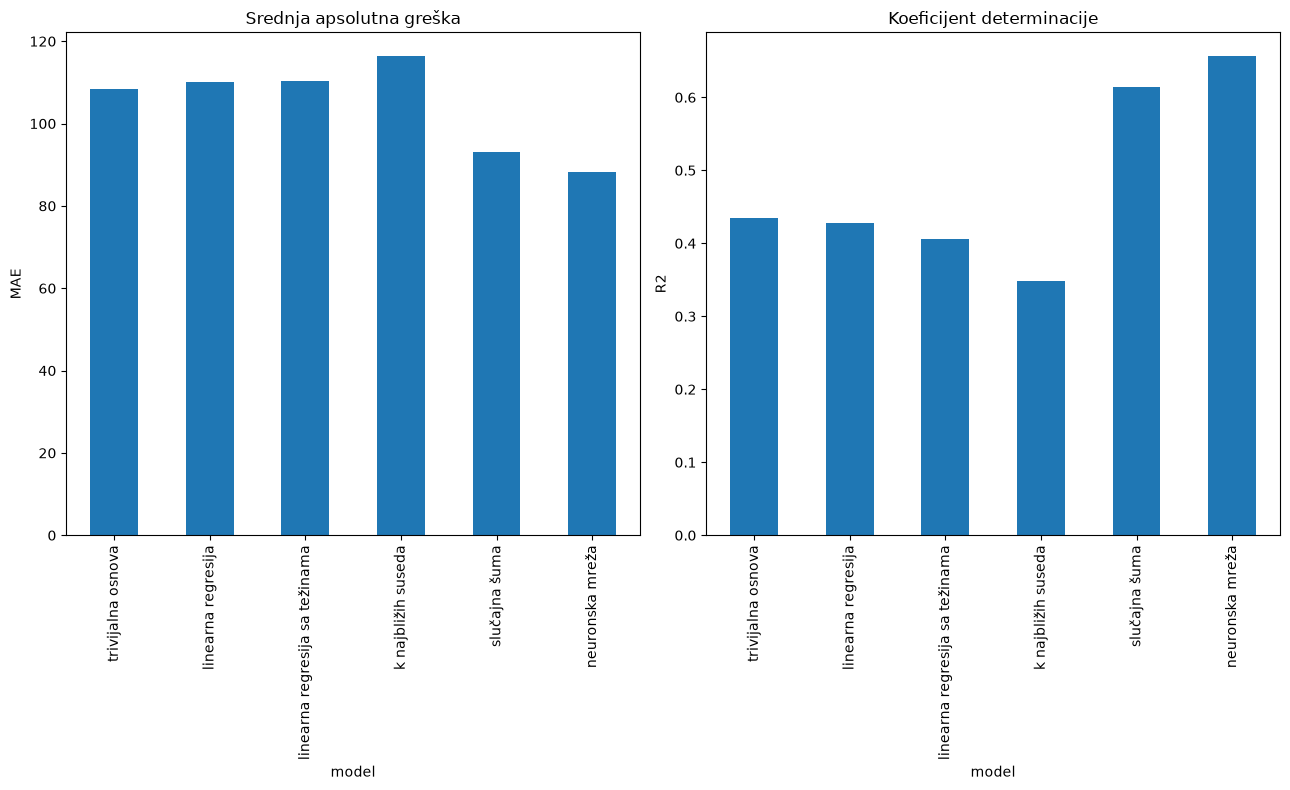

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(13, 8))

tabela_rezultata['MAE'].plot(kind='bar', ax=ax[0])
ax[0].set_title('Srednja apsolutna greška')
ax[0].set_ylabel('MAE')

tabela_rezultata['R2'].plot(kind='bar', ax=ax[1])
ax[1].set_title('Koeficijent determinacije')
ax[1].set_ylabel('R2')

plt.tight_layout()
plt.show()

# Čuvanje modela

Keras model čuvamo u sopstvenom formatu, a skaler i tabelu rezultata kao i ranije.

In [38]:
model_mreza.save('../models/06_mreza.keras')
joblib.dump(scaler_final, '../models/06_scaler.joblib')

tabela_rezultata.to_csv('../models/06_rezultati.csv')

print('sačuvano')

sačuvano


Proveravamo da se sačuvani model može učitati i da daje ista predviđanja.

In [39]:
from tensorflow.keras.models import load_model

ucitani_model = load_model('../models/06_mreza.keras')
y_ucitani = np.maximum(ucitani_model.predict(x_test_s, verbose=0).ravel(), 0)

print('najveća razlika u predviđanjima:', np.abs(y_ucitani - y_test_predicted_mreza).max())

najveća razlika u predviđanjima: 0.0


# Zaključci

1. Potpuno povezana neuronska mreža sa dva skrivena sloja od po 128 neurona je najbolji
   model na hronološkoj podeli, sa srednjom apsolutnom greškom ispod 90 bicikala
   i koeficijentom determinacije oko 0.65.

2. Bez ranog zaustavljanja mreža se preprilagođava: greška na treningu nastavlja
   da opada dok greška na validaciji raste. Rano zaustavljanje rešava i izbor broja
   epoha i regularizaciju.

3. Ni širina ni dubina same po sebi ne donose mnogo: jedan sloj bilo koje širine i dva uska sloja daju grešku oko 37 bicikala na validaciji. Tek dva sloja od 128 neurona spuštaju grešku na 31.4, a treći sloj ne donosi dalje poboljšanje.

4. Mreža, kao i svi modeli pre nje, potcenjuje potražnju u 2012. za oko 80 bicikala
   po satu. Oblik dnevnog profila pogađa tačno, nivo ne. To ograničenje dolazi iz
   podataka, a ne iz modela.

5. Na nasumičnoj podeli mreža ima grešku tri puta manju nego na hronološkoj. Razlika
   je najveća upravo kod najjačeg modela, pa nasumična podela najviše obmanjuje tamo
   gde bi rezultat izgledao najbolje.